<a href="https://colab.research.google.com/github/mgmarce/dataset_py4/blob/main/Marcela_Menjivar_PY4_M1S4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Visualización — Práctica Individual
**Bootcamp Python PY4 · Módulo 1 · Semana 4**

---

Este notebook es tu espacio de trabajo para el proyecto de cierre del módulo.
A diferencia de las sesiones anteriores, aquí tú tomas las decisiones:
qué datos explorar, qué preguntas hacer, y qué historia contar.

El trabajo se organiza en cuatro etapas:

1. Selección y carga de datos
2. Análisis exploratorio (EDA)
3. Estrategia de visualización con apoyo de IA
4. Construcción de las tres visualizaciones con narrativa

**Entrega:** un único archivo `.ipynb` que corre sin errores de principio a fin.


## 1. Setup

Importa todas las librerías que vas a necesitar en esta celda.
Si necesitas instalar algo, hazlo aquí también.


In [43]:
# Instalación (descomenta si es necesario)
# !pip install altair plotly seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import altair as alt

sns.set_theme(style="white", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


---
## 2. Selección y carga de datos

Elige uno de los tres datasets disponibles, o trae el tuyo propio.
Lee la descripción de cada uno antes de decidir.

---

### Opción A — Video Games
Ventas y puntuaciones de videojuegos entre 1977 y 2023.
Contiene: título, consola, género, publisher, puntuación de crítica,
ventas por región (Norteamérica, Japón, Europa, otros) y fecha de lanzamiento.
Preguntas posibles: ¿qué géneros venden más? ¿hay diferencias regionales?
¿existe relación entre la puntuación y las ventas?

```python
# BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"
# df = pd.read_csv(BASE_URL + "video_game_dataset.csv")
```

---

### Opción B — Olympics
Resultados de los Juegos Olímpicos de 1896 a 2016.
Contiene: nombre del atleta, sexo, edad, altura, peso, país, deporte,
evento y medalla obtenida.
Preguntas posibles: ¿cómo ha evolucionado la participación femenina?
¿qué países dominan ciertos deportes? ¿existe relación entre el físico y el deporte?

```python
# BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"
# df = pd.read_csv(BASE_URL + "olympic_dataset.csv")
```

---

### Opción C — Coffee Shop Sales
Transacciones de una cadena de cafeterías en Nueva York durante 2023.
Contiene: fecha, hora, ubicación, producto, categoría, cantidad y precio.
Preguntas posibles: ¿cuáles son los productos más vendidos? ¿hay patrones
por hora del día o día de la semana? ¿qué tienda genera más ingresos?

```python
# BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"
# df = pd.read_csv(BASE_URL + "coffee_shop_sales_dataset.csv")
```

---

### Opción D — Dataset propio
Si traes tu propio dataset, cárgalo aquí y asegúrate de subir tu dataset con el notebook finalizado (o modifica el notebook para descargar directamente el dataset desde aqui).

```python
# Desde archivo local
# df = pd.read_csv("tu_archivo.csv")

# Desde URL
# df = pd.read_csv("https://url-de-tu-dataset.csv")

BASE_URL = "https://raw.githubusercontent.com/mgmarce/dataset_py4/main/"
df = pd.read_csv(BASE_URL + "JLPT_kanji_master_list.csv")

```


### Dataset elegido

Indica aquí cuál elegiste :

**Dataset:** *[Opción A / B / C / D — nombre del dataset]*



In [44]:
# Carga tu dataset aquí
# Descomenta la opción que elegiste o escribe tu propia carga

BASE_URL = "https://raw.githubusercontent.com/mgmarce/dataset_py4/main/"


# Opción A
# df = pd.read_csv(BASE_URL + "video_game_dataset.csv")

# Opción B
# df = pd.read_csv(BASE_URL + "olympic_dataset.csv")

# Opción C
# df = pd.read_csv(BASE_URL + "coffee_shop_sales_dataset.csv")

# Opción D — dataset propio
df = pd.read_csv(BASE_URL + "JLPT_kanji_master_list.csv")

# Vista inicial
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 2,383  |  Columnas: 20


,id,kanji,JLPT_level,jouyou_index,kyouiku_grade,in_prefectures,strokes,stroke_order_url,rad_num,rad_glyph,onyomi,kunyomi,romaji_on,romaji_kun,meaning,rank,easiness,interval,repetition,next_review
0,6adafafc-73f8-4951-b08c-fd7b8de55041,一,N5,41,Grade 1,0,1,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,"イチ, イツ","ひと-, ひと.つ","ichi, itsu","hito-, hito.tsu","one, one radical (no.1), un",41,2.5,0,0,2026-05-02
1,07678e73-7dd4-4192-9e29-dccd2fd42017,丁,N1,1392,Grade 3,0,2,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,"チョウ, テイ, チン, トウ, チ",ひのと,"chou, tei, chin, tou, chi",hinoto,"street, ward, town",766,2.5,0,0,2026-05-02
2,5c9519d0-c7b1-483d-b639-c56486b1681d,七,N5,829,Grade 1,0,2,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,シチ,"なな, なな.つ, なの",shichi,"nana, nana.tsu, nano","seven, sept, siete",759,2.5,0,0,2026-05-02
3,1f2633bb-a010-4a16-a46f-f2456a80df29,万,N5,1906,Grade 2,0,3,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,"マン, バン",よろず,"man, ban",yorozu,"ten thousand, 10,000, myriade",124,2.5,0,0,2026-05-02
4,96af1d17-4561-4d2c-b54f-6a28ca7f52e8,丈,N1,1010,High School,0,3,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,ジョウ,"たけ, だけ",jou,"take, dake","length, ten shaku, measure",798,2.5,0,0,2026-05-02


---
## 3. Análisis exploratorio (EDA)

El objetivo del EDA no es hacer gráficos todavía.
Es entender la estructura de los datos para tomar buenas decisiones
de visualización después.

Responde las siguientes preguntas con código.


### 3.1 Estructura general

¿Cuántas filas y columnas tiene el dataset?
¿Qué tipo de dato tiene cada columna?
¿Hay valores nulos?


In [45]:
# Tipos de datos y valores no nulos
# Dimensiones
print("Filas y columnas:", df.shape)

# Tipos de datos
display(df.info())

# Primeras filas
df.head()


Filas y columnas: (2383, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2383 entries, 0 to 2382
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2383 non-null   object 
 1   kanji             2383 non-null   object 
 2   JLPT_level        2383 non-null   object 
 3   jouyou_index      2383 non-null   int64  
 4   kyouiku_grade     2383 non-null   object 
 5   in_prefectures    2383 non-null   int64  
 6   strokes           2383 non-null   int64  
 7   stroke_order_url  2383 non-null   object 
 8   rad_num           2383 non-null   int64  
 9   rad_glyph         2383 non-null   object 
 10  onyomi            2371 non-null   object 
 11  kunyomi           1982 non-null   object 
 12  romaji_on         2369 non-null   object 
 13  romaji_kun        1982 non-null   object 
 14  meaning           2381 non-null   object 
 15  rank              2383 non-null   int64  
 16  easiness     

None

,id,kanji,JLPT_level,jouyou_index,kyouiku_grade,in_prefectures,strokes,stroke_order_url,rad_num,rad_glyph,onyomi,kunyomi,romaji_on,romaji_kun,meaning,rank,easiness,interval,repetition,next_review
0,6adafafc-73f8-4951-b08c-fd7b8de55041,一,N5,41,Grade 1,0,1,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,"イチ, イツ","ひと-, ひと.つ","ichi, itsu","hito-, hito.tsu","one, one radical (no.1), un",41,2.5,0,0,2026-05-02
1,07678e73-7dd4-4192-9e29-dccd2fd42017,丁,N1,1392,Grade 3,0,2,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,"チョウ, テイ, チン, トウ, チ",ひのと,"chou, tei, chin, tou, chi",hinoto,"street, ward, town",766,2.5,0,0,2026-05-02
2,5c9519d0-c7b1-483d-b639-c56486b1681d,七,N5,829,Grade 1,0,2,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,シチ,"なな, なな.つ, なの",shichi,"nana, nana.tsu, nano","seven, sept, siete",759,2.5,0,0,2026-05-02
3,1f2633bb-a010-4a16-a46f-f2456a80df29,万,N5,1906,Grade 2,0,3,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,"マン, バン",よろず,"man, ban",yorozu,"ten thousand, 10,000, myriade",124,2.5,0,0,2026-05-02
4,96af1d17-4561-4d2c-b54f-6a28ca7f52e8,丈,N1,1010,High School,0,3,https://raw.githubusercontent.com/KanjiVG/kanj...,1,⼀,ジョウ,"たけ, だけ",jou,"take, dake","length, ten shaku, measure",798,2.5,0,0,2026-05-02


In [46]:
# Valores nulos por columna
df.isnull().sum().sort_values(ascending=False)


,0
romaji_kun,401
kunyomi,401
romaji_on,14
onyomi,12
meaning,2
JLPT_level,0
kanji,0
id,0
jouyou_index,0
stroke_order_url,0


### 3.2 Variables numéricas

¿Cuál es el rango, la media y la distribución de las variables numéricas?


In [47]:
# Estadísticas descriptivas de columnas numéricas
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
jouyou_index,2383.0,957.749056,668.624150,0.0,349.5,945.0,1540.5,2136.0
in_prefectures,2383.0,0.030634,0.172359,0.0,0.0,0.0,0.0,1.0
strokes,2383.0,10.554343,3.803789,1.0,8.0,10.0,13.0,29.0
rad_num,2383.0,88.814939,52.988146,1.0,43.5,85.0,137.0,211.0
rank,2383.0,634.858162,235.043146,1.0,508.5,751.0,817.0,830.0
easiness,2383.0,2.500000,0.000000,2.5,2.5,2.5,2.5,2.5
interval,2383.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
repetition,2383.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


### 3.3 Variables categóricas

¿Cuántos valores únicos tiene cada variable categórica?
¿Cuáles son los más frecuentes?


In [48]:
# Columnas categóricas: valores únicos y top 5 más frecuentes
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print("="*60)
    print(col)
    print("Valores únicos:", df[col].nunique())
    print(df[col].value_counts().head())


id
Valores únicos: 2383
id
64fc9291-08a6-4adb-a466-a352b619b3d5    1
6adafafc-73f8-4951-b08c-fd7b8de55041    1
07678e73-7dd4-4192-9e29-dccd2fd42017    1
5c9519d0-c7b1-483d-b639-c56486b1681d    1
1f2633bb-a010-4a16-a46f-f2456a80df29    1
Name: count, dtype: int64
kanji
Valores únicos: 2383
kanji
𠮟    1
一    1
丁    1
七    1
万    1
Name: count, dtype: int64
JLPT_level
Valores únicos: 5
JLPT_level
N1    1390
N3     377
N2     368
N4     168
N5      80
Name: count, dtype: int64
kyouiku_grade
Valores únicos: 8
kyouiku_grade
High School           1110
Tertiary Education     247
Grade 4                202
Grade 3                200
Grade 5                193
Name: count, dtype: int64
stroke_order_url
Valores únicos: 2383
stroke_order_url
https://raw.githubusercontent.com/KanjiVG/kanjivg/master/kanji/20b9f.svg    1
https://raw.githubusercontent.com/KanjiVG/kanjivg/master/kanji/04e00.svg    1
https://raw.githubusercontent.com/KanjiVG/kanjivg/master/kanji/04e01.svg    1
https://raw.githubusercont

### 3.4 Limpieza mínima

Basándote en lo que encontraste arriba, realiza la limpieza necesaria.
No tienes que limpiar todo — solo lo que afecte a las visualizaciones que planeas hacer.

Documenta cada decisión con un comentario en el código.


In [49]:
# Limpieza de datos
# Explica con comentarios qué estás haciendo y por qué

# Ejemplo:
# df = df.dropna(subset=["columna_clave"])   # eliminamos filas sin valor en la columna principal
# df["columna"] = df["columna"].str.strip()  # eliminamos espacios en nombres

# Tu código aquí:

# Eliminamos filas sin significado
df = df.dropna(subset=["meaning"])

# Eliminamos espacios innecesarios
df["meaning"] = df["meaning"].str.strip()

print(f"Dataset después de limpieza: {df.shape[0]:,} filas x {df.shape[1]} columnas")

print(f"Dataset después de limpieza: {df.shape[0]:,} filas x {df.shape[1]} columnas")


Dataset después de limpieza: 2,381 filas x 20 columnas
Dataset después de limpieza: 2,381 filas x 20 columnas


### 3.5 Observación principal del EDA

Antes de pasar a las visualizaciones, escribe en una o dos frases
la observación más interesante que encontraste durante el EDA.
Esto va a guiar tu estrategia de visualización.


*La mayor parte de los kanjis pertenecen al nivel JLPT N1, mientras que los niveles básicos contienen muchos menos caracteres. También se observa que la cantidad de trazos varía considerablemente, lo que podría relacionarse con la dificultad de aprendizaje.*


---
## 4. Estrategia de visualización con IA

Antes de escribir código, consulta con una herramienta de IA
(ChatGPT, Claude u otra) para definir qué visualizaciones construir.

### Instrucciones

1. Formula un prompt describiendo tu dataset y tus objetivos.
2. La respuesta **debe incluir al menos tres sugerencias de gráficos,
   una con Matplotlib/Seaborn, una con Plotly y una con Altair**.
3. Cada gráfico debe responder a una pregunta diferente.
4. Selecciona las tres que más te convenzan y pégalas abajo.
5. Si la primera respuesta no es satisfactoria, refina el prompt e itera.

### Guía para escribir un buen prompt

Un prompt efectivo incluye:
- Descripción del dataset (columnas, tipos de datos, tamaño)
- El objetivo: qué historia quieres contar
- Las herramientas que tienes que usar
- El nivel de detalle que esperas en la respuesta

Ejemplo de estructura:

> *"Tengo un dataset de [descripción]. Las columnas principales son [lista].
> Quiero construir un dashboard EDA en Python usando Seaborn, Plotly y Altair.
> Sugiere 3 visualizaciones, una por librería, que respondan cada una
> a una pregunta distinta sobre los datos. Justifica cada elección."*


### Prompt utilizado

> *Tengo un dataset sobre kanjis japoneses del examen JLPT. Contiene el nivel JLPT, cantidad de trazos, radical, grado escolar japonés, significado, lecturas y otras variables. Necesito tres visualizaciones para un proyecto de análisis de datos: una usando Matplotlib o Seaborn, una usando Plotly y una usando Altair. Cada gráfico debe responder una pregunta diferente y contar una historia sobre los datos.*

---

### Prompt refinado (si aplicó)

> *-*

---

### Visualizaciones seleccionadas

#### Viz 1 — [Gráfico de barras de cantidad ed kanjis por nivel JLPT] (Seaborn)
**Pregunta que responde:** *¿Qué nivel del JLPT contiene más kanjis?*

---

#### Viz 2 — [Histograma interactivo de cantidad de trazos] (Plotly)
**Pregunta que responde:** *¿Cómo se distribuye el número de trazos de los kanjis?*

---

#### Viz 3 — [Boxplot de trazos por nivel JLPT] (Altair)
**Pregunta que responde:** *¿Los niveles más avanzados contienen kanjis más complejos?*


---
## 5. Visualización 1 — Matplotlib / Seaborn

**Pregunta:** *¿Qué nivel del JLPT contiene más kanjis?*

### Criterios de diseño a aplicar

Antes de programar, piensa en estos tres principios:

- **Ratio datos-tinta:** ¿hay bordes, rellenos o líneas de cuadrícula que puedas eliminar
  sin perder información?
- **Jerarquía visual:** ¿qué elemento quieres que el lector vea primero?
  Usa color, tamaño o posición para destacarlo.
- **Color con significado:** cada color debe justificarse.
  Si usas una paleta, elige una que refuerce el mensaje
  (por ejemplo, paleta divergente para comparar dos extremos,
  paleta secuencial para intensidad).

Puedes pedirle a la IA que te ayude a escribir el código, pero revisa
cada línea y asegúrate de entender qué hace.


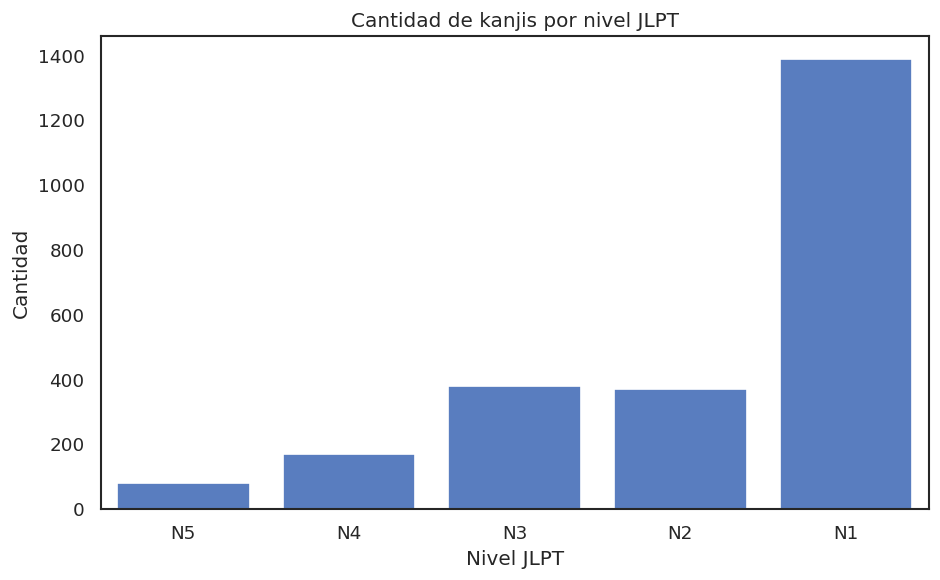

In [50]:
# Visualización 1 — Matplotlib / Seaborn

# Tu código aquí
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="JLPT_level",
    order=["N5","N4","N3","N2","N1"]
)

plt.title("Cantidad de kanjis por nivel JLPT")
plt.xlabel("Nivel JLPT")
plt.ylabel("Cantidad")

plt.tight_layout()
plt.show()


### Historia / mensaje de la Viz 1

Escribe en dos o tres frases la historia que cuenta este gráfico.
Estructura sugerida:

- **¿Qué muestra el gráfico?** *(observación objetiva)*
- **¿Por qué es relevante?** *(contexto o implicación)*
- **¿Qué decisión o acción sugiere?**

*El gráfico muestra que el nivel N1 contiene la mayor cantidad de kanjis del dataset. Esto refleja que los niveles avanzados requieren dominar un vocabulario mucho más amplio que los niveles iniciales. Esta información puede ayudar a planificar el estudio de acuerdo con la dificultad.*


---
## 6. Visualización 2 — Plotly

**Pregunta:** *¿Cómo se distribuye el número de trazos de los kanjis?*

### Lo que la interactividad debe agregar

La interactividad de Plotly no es un fin en sí mismo.
Pregúntate: ¿qué puede descubrir el usuario al hacer hover o zoom
que no podría ver en un gráfico estático?

Si la respuesta es "nada", el gráfico no necesita ser interactivo.

Configura el hover para que muestre exactamente la información
que responde la pregunta. Nada más, nada menos.


In [51]:
# Visualización 2 — Plotly

# Tu código aquí

fig = px.histogram(
    df,
    x="strokes",
    nbins=20,
    title="Distribución de la cantidad de trazos"
)

fig.update_layout(
    xaxis_title="Número de trazos",
    yaxis_title="Cantidad de kanjis"
)

fig.show()


### Historia / mensaje de la Viz 2

- **¿Qué muestra el gráfico?**
- **¿Qué descubre el usuario al interactuar con él?**
- **¿Qué decisión o acción sugiere?**

*La distribución muestra que la mayoría de los kanjis poseen entre 6 y 15 trazos. Gracias a la interactividad es posible identificar fácilmente los valores extremos y explorar cada intervalo de trazos con mayor detalle.*


---
## 7. Visualización 3 — Altair

**Pregunta:** *¿Los niveles más avanzados contienen kanjis más complejos?*


In [52]:
# Visualización 3 — Altair


# Tu código aquí

chart = alt.Chart(df).mark_boxplot().encode(
    x="JLPT_level:N",
    y="strokes:Q",
    tooltip=["JLPT_level","strokes"]
).properties(
    width=600,
    height=400,
    title="Cantidad de trazos por nivel JLPT"
)

chart


alt.Chart(...)

### Historia / mensaje de la Viz 3

- **¿Qué muestra el gráfico?**
- **¿Qué permite descubrir la interacción?**
- **¿Qué decisión o acción sugiere?**

*El boxplot permite comparar la distribución de trazos entre los diferentes niveles del JLPT. Se observa que los niveles superiores presentan una mayor variabilidad y algunos caracteres con un número elevado de trazos, lo que puede indicar una mayor complejidad gráfica.*


---
## Checklist de entrega

| Criterio | Descripción | Listo |
|---|---|---|
| Formato | Archivo único `.ipynb` | [ ] |
| Ejecución | Corre de principio a fin sin errores | [ ] |
| Dataset | Celda con la elección y la razón | [ ] |
| EDA | Nulos, descriptivas, categóricas y limpieza documentados | [ ] |
| Prompt | Prompt original pegado sin modificar | [ ] |
| Estrategia | Tres gráficos seleccionados con pregunta y justificación | [ ] |
| Viz 1 | Matplotlib/Seaborn con principios de diseño aplicados | [ ] |
| Viz 2 | Plotly con hover configurado para responder la pregunta | [ ] |
| Viz 3 | Altair con al menos un elemento de interacción | [ ] |
| Narrativa | Historia escrita debajo de cada visualización | [ ] |

---
*Bootcamp Python PY4 · Módulo 1 · Semana 4 · Kodigo Academia de Tecnología Creativa*
